# Unconstrained optimization

This page demonstrates how to minimize an unconstrained continuous function. First, the minimize method must be imported.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt_optim import minimize

## Unconstrained optimization of a 1D function

### Defining the test problem

The following example shows how to optimize the Forrester test function. The cell below defines and plots the function. Our objective is to find the minimum of the function.


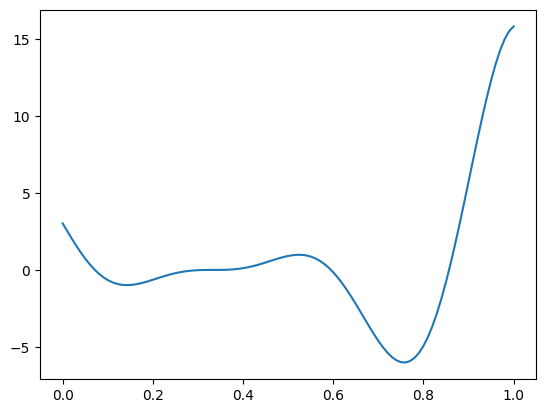

In [2]:
def forrester(x):
    return (6*x - 2)**2 * np.sin(12*x - 4)

bounds = np.array([
    [0, 1]
])

x_valid = np.linspace(0, 1, 101)
y_valid = forrester(x_valid)

fig, ax = plt.subplots()
ax.plot(x_valid, y_valid)
plt.show()

### Starting the optimization

The easiest way to begin Bayesian optimization is to use the `minimize` method. Two arguments must be passed:

- `objective`: the function to minimize;
- `design_space`: the function boundary.

Because the `objective` parameter requires a list, we place our objective function within a list. The `design_space` parameter can accept either a `DesignSpace` class or a `np.ndarray`. Providing a `np.ndarray` will assume the design space is entirely continuous.

Moreover, we can also pass the following optional arguments:

- `max_iter`: the maximum number of iterations before the program stops
- `driver_kwargs`: kwargs to pass to the optimization driver. In our case, we pass the `seed` parameter to make this example reproducible.

All minimize parameters can be viewed using: help(minimize). The minimize method returns a State object containing the design of experiment (DoE) with all function samples. We can find the best function value during the optimization process using these samples.


In [3]:
state = minimize([forrester], bounds, max_iter=20, driver_kwargs={"seed": 0})

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1              6   -9.48494e-01      0.000e+00              1          0.016          0.018
             2              7   -9.48494e-01      0.000e+00              1          0.015          0.019
             3              8   -5.26432e+00      0.000e+00              1          0.017          0.023
             4              9   -5.26432e+00      0.000e+00              1          0.018          0.018
             5             10   -5.26432e+00      0.000e+00              1          0.018          0.011
             6             11   -5.26432e+00      0.000e+00              1          0.018          0.012
             7             12   -5.26432e+00      0.000e+00              1          0.018          0.010
             8             13   -5.26432e+00      0.000e+00              1          0.019          0.008
             9             14   -5.26432e+00      0.000

We can retrieve the best function sample using the `get_best_sample` class method. This returns a `Sample` object containing data such as:

- `x`: the design point
- `obj`: the objective value at `x`
- `eval_time`: the elapsed time to sample the objective.

The `Sample` object also contains some metadata:

- `iter`: the iteration at which the function was sampled
- `budget`: the budget after sampling the function

By default, one unit of budget is equivalent to one function evaluation.


In [4]:
best_sample = state.get_best_sample()
best_sample

======= sample data =======
x =             [0.76498757]
obj =           [-5.98807597]
cstr =          []
eval_time =     [9.43100167e-06]
------- meta data -------
iter =     18
budget =     23
fidelity =     0
rscv =     0.0

### Plotting the results

The code snippet below exports all the evaluated design points and their corresponding objective values, plotting them against the function. The best sample is marked with a star.

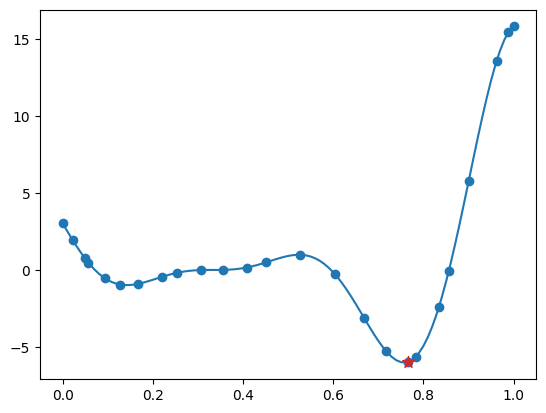

In [5]:
x_doe = state.dataset.export_as_dict()["x"]
y_doe = state.dataset.export_as_dict()["obj"]

fig, ax = plt.subplots()
ax.plot(x_valid, y_valid)
ax.scatter(x_doe, y_doe)
ax.scatter(best_sample.x[0], best_sample.obj[0], 75, color="C3", marker="*", zorder=30)
plt.show()